In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# RemoteOK headers - real browser jaisa lagega
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Referer": "https://www.google.com"
}

url = "https://remoteok.com/remote-dev-jobs"

# 3 second wait - robot nahi lagenge
time.sleep(3)

response = requests.get(url, headers=headers, timeout=15)
print(f"Status Code: {response.status_code}")

Status Code: 200


In [ ]:
# Step 3: Website ka HTML lao
soup = BeautifulSoup(response.content, "html.parser")

# Job cards dhundo
jobs = soup.find_all("tr", class_="job")

# Kitni jobs mili
print(f"Total Jobs : {len(jobs)}")

Total Jobs Mili: 9


In [ ]:
# Step 4: Har job ki details nikalo
job_list = []

for job in jobs:
    try:
        # Job Title
        title = job.find("h2", itemprop="title")
        title = title.text.strip() if title else "N/A"

        # Company Name
        company = job.find("h3", itemprop="name")
        company = company.text.strip() if company else "N/A"

        # Location
        location = job.find("div", class_="location")
        location = location.text.strip() if location else "Remote"

        # Tags/Skills
        tags = job.find_all("div", class_="tag")
        tags = [tag.text.strip() for tag in tags] if tags else []

        # Salary
        salary = job.find("div", class_="salary")
        salary = salary.text.strip() if salary else "Not Mentioned"

        # Sab store karo
        job_list.append({
            "Title": title,
            "Company": company,
            "Location": location,
            "Tags": ", ".join(tags),
            "Salary": salary
        })

    except Exception as e:
        print(f"Error: {e}")
        continue

print(f" {len(job_list)} ")

✅ 9 Jobs Ki Details Nikal Li!


In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# JSON API use karo - bohot asaan!
url = "https://remoteok.com/remote-dev-jobs.json"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0"
}

import time
time.sleep(3)

response = requests.get(url, headers=headers)
data = response.json()

# Pehla item skip karo (metadata hota hai)
jobs = data[1:]

print(f"✅ Total Jobs Mili: {len(jobs)}")
print(f"\nPehli Job:")
print(jobs[0])

✅ Total Jobs Mili: 100

Pehli Job:
{'slug': 'remote-senior-backend-engineer-studio-ai-creative-fabrica-1133667', 'id': '1133667', 'epoch': 1781802002, 'date': '2026-06-18T17:00:02+00:00', 'company': 'Creative Fabrica', 'company_logo': '', 'position': 'Senior Backend Engineer Studio AI', 'tags': ['golang', 'technical', 'dev', 'senior', 'engineer', 'backend', 'digital nomad'], 'description': "Remote - About Creative FabricaCreative Fabrica is a subscription platform serving millions of creators, designers, and crafters worldwide. We're built on the principle that everyone can be creative. We remove what stands in the way: expensive software, technical expertise, an...<br/><br/>Please mention the word **PROLIFIC** and tag RMzkuNTguNTYuOTY= when applying to show you read the job post completely (#RMzkuNTguNTYuOTY=). This is a beta feature to avoid spam applicants. Companies can search these words to find applicants that read this and see they're human.", 'location': '', 'apply_url': 'https

In [11]:
# Step 6: Clean DataFrame banao
job_list = []

for job in jobs:
    job_list.append({
        "Title": job.get("position", "N/A"),
        "Company": job.get("company", "N/A"),
        "Location": job.get("location", "Remote"),
        "Tags": ", ".join(job.get("tags", [])),
        "Salary Min": job.get("salary_min", 0),
        "Salary Max": job.get("salary_max", 0),
        "Date Posted": job.get("date", "N/A"),
        "Apply URL": job.get("apply_url", "N/A")
    })

# DataFrame banao
df = pd.DataFrame(job_list)

# Table dikhao
print(f"✅ Total Jobs: {len(df)}")
print(f"✅ Columns: {list(df.columns)}")
df.head()

✅ Total Jobs: 100
✅ Columns: ['Title', 'Company', 'Location', 'Tags', 'Salary Min', 'Salary Max', 'Date Posted', 'Apply URL']


,Title,Company,Location,Tags,Salary Min,Salary Max,Date Posted,Apply URL
0,Senior Backend Engineer Studio AI,Creative Fabrica,,"golang, technical, dev, senior, engineer, back...",0,0,2026-06-18T17:00:02+00:00,https://remoteOK.com/remote-jobs/remote-senior...
1,Graphic Designer,Swoon,"New York, New York, United States","hr, virtual assistant, medical, customer suppo...",0,0,2026-06-18T15:14:38+00:00,https://remoteOK.com/remote-jobs/remote-graphi...
2,VP Strategic Customer Programs,Karbon,"Chicago, Chicago, Illinois, United States","data entry, virtual assistant, customer suppor...",0,0,2026-06-18T14:58:47+00:00,https://remoteOK.com/remote-jobs/remote-vp-str...
3,VP GM East &amp; Control,"Mast-JÃ¤germeister US, Inc.","White Plains, White Plains, New York, United S...","hr, virtual assistant, medical, customer suppo...",0,0,2026-06-18T14:46:34+00:00,https://remoteOK.com/remote-jobs/remote-vp-gm-...
4,Scrum Master,Blackstone Talent Group,Dallas-Fort Worth Metroplex,"hr, virtual assistant, medical, customer suppo...",0,0,2026-06-18T12:16:30+00:00,https://remoteOK.com/remote-jobs/remote-scrum-...


In [12]:
# Step 7: Data Clean Karo

# 1. Date column clean karo
df["Date Posted"] = pd.to_datetime(df["Date Posted"]).dt.date

# 2. Location clean karo - sirf country rakho
df["Country"] = df["Location"].apply(lambda x: x.split(",")[-1].strip() if "," in x else x.strip())

# 3. Salary 0 wali jobs ko "Not Mentioned" karo
df["Salary Range"] = df.apply(lambda x: 
    f"${x['Salary Min']:,} - ${x['Salary Max']:,}" 
    if x['Salary Min'] > 0 
    else "Not Mentioned", axis=1)

# 4. Duplicates hatao
df = df.drop_duplicates(subset=["Title", "Company"])

print(f"✅ Clean Jobs: {len(df)}")
print(f"✅ Countries: {df['Country'].nunique()}")
print(f"\nTop 5 Countries:")
print(df["Country"].value_counts().head())

✅ Clean Jobs: 94
✅ Countries: 24

Top 5 Countries:
Country
                  39
United States     28
United Kingdom     3
Remote             2
France             2
Name: count, dtype: int64


In [13]:
# Empty country fix karo
df["Country"] = df["Country"].replace("", "Not Specified")
df["Country"] = df["Country"].str.strip()

# Peru encoding fix karo
df["Country"] = df["Country"].str.encode('latin-1').str.decode('utf-8', errors='ignore')

# Ab top countries dekho
print("✅ Top 10 Countries:")
print(df["Country"].value_counts().head(10))

✅ Top 10 Countries:
Country
Not Specified                  39
United States                  28
United Kingdom                  3
Remote                          2
France                          2
Canada                          2
Dallas-Fort Worth Metroplex     1
المدينة المدينة السعودية        1
California                      1
UK                              1
Name: count, dtype: int64


In [14]:
# Step 8: Analysis

# 1. Top 10 Job Titles
print("🔥 Top 10 Job Titles:")
print(df["Title"].value_counts().head(10))

print("\n")

# 2. Top 10 Companies
print("🏢 Top 10 Companies:")
print(df["Company"].value_counts().head(10))

print("\n")

# 3. Salary info
print("💰 Salary Info:")
has_salary = df[df["Salary Range"] != "Not Mentioned"]
print(f"Jobs with Salary: {len(has_salary)}")
print(f"Jobs without Salary: {len(df) - len(has_salary)}")

🔥 Top 10 Job Titles:
Title
Executive Assistant                      3
Graphic Designer                         2
Scrum Master                             2
Business Development Representative      2
Administrative Assistant                 2
VP GM East &amp; Control                 1
Social Media Manager                     1
VP Strategic Customer Programs           1
Social Content Designer & Producer       1
Interested future Corporate positions    1
Name: count, dtype: int64


🏢 Top 10 Companies:
Company
Somewhere                  3
NOBLE                      2
OnlineJobs.PH              2
PBG                        2
Work Force Nexus           2
Classet                    2
Papillon Patrimoine        2
Crypto.com                 1
Zyte                       1
Blackstone Talent Group    1
Name: count, dtype: int64


💰 Salary Info:
Jobs with Salary: 1
Jobs without Salary: 93


C:\Users\PC\AppData\Local\Temp\ipykernel_43584\3700105635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette="viridis")


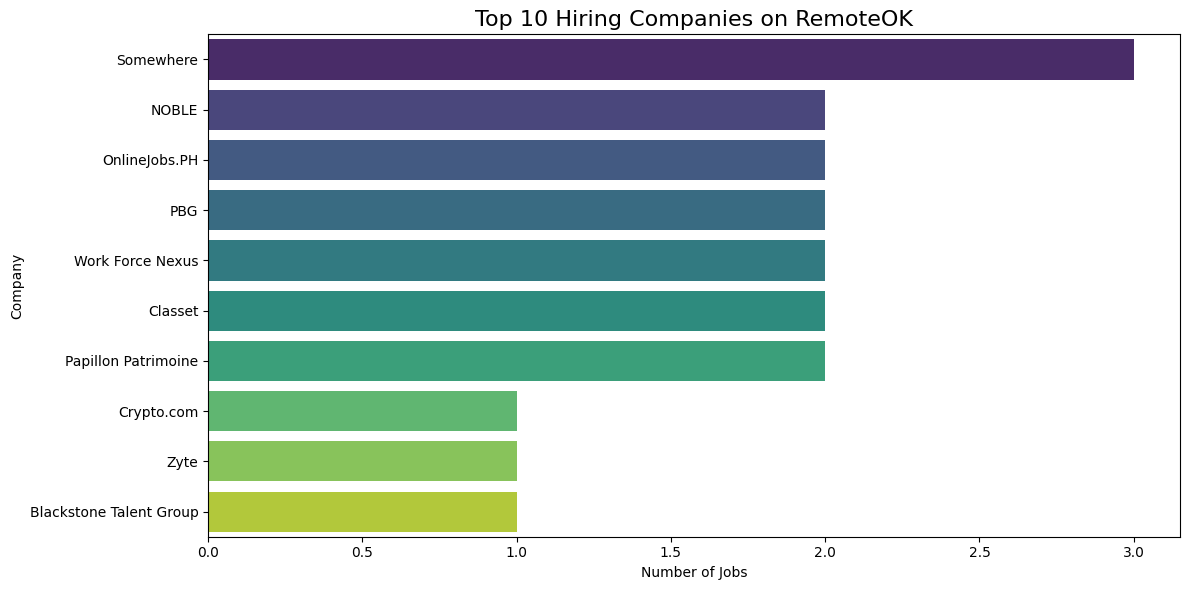

✅ Chart 1 Done!


In [15]:
# Chart 1: Top 10 Companies
plt.figure(figsize=(12, 6))
top_companies = df["Company"].value_counts().head(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette="viridis")
plt.title("Top 10 Hiring Companies on RemoteOK", fontsize=16)
plt.xlabel("Number of Jobs")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig("top_companies.png")
plt.show()
print("✅ Chart 1 Done!")

C:\Users\PC\AppData\Local\Temp\ipykernel_43584\1408232411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")


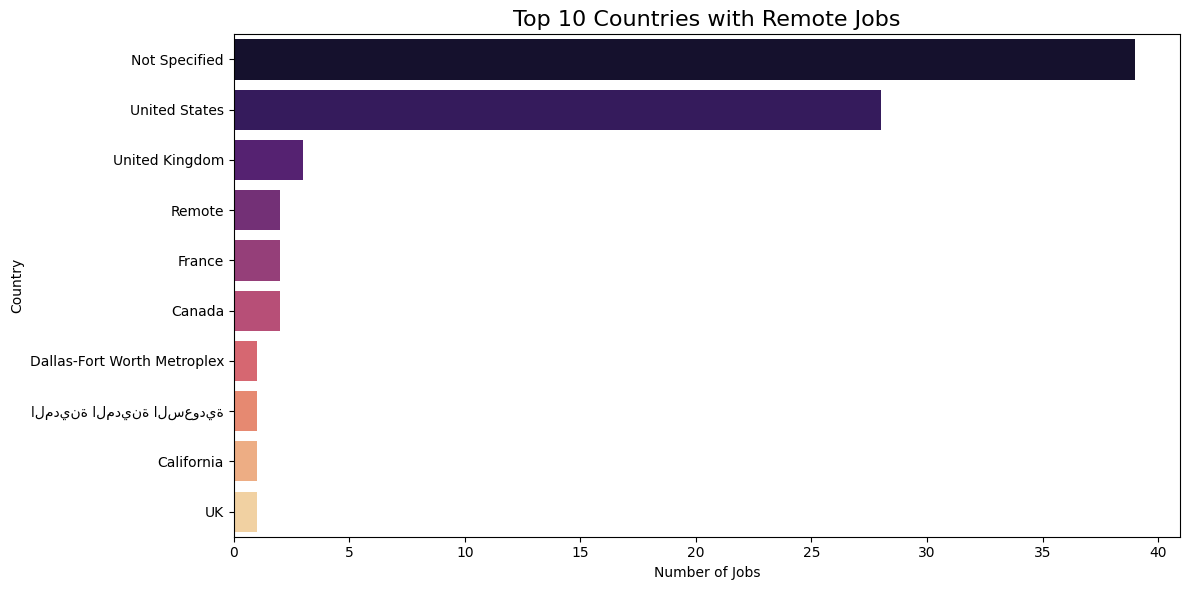

✅ Chart 2 Done!


In [16]:
# Chart 2: Top 10 Countries
plt.figure(figsize=(12, 6))
top_countries = df["Country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 10 Countries with Remote Jobs", fontsize=16)
plt.xlabel("Number of Jobs")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries.png")
plt.show()
print("✅ Chart 2 Done!")

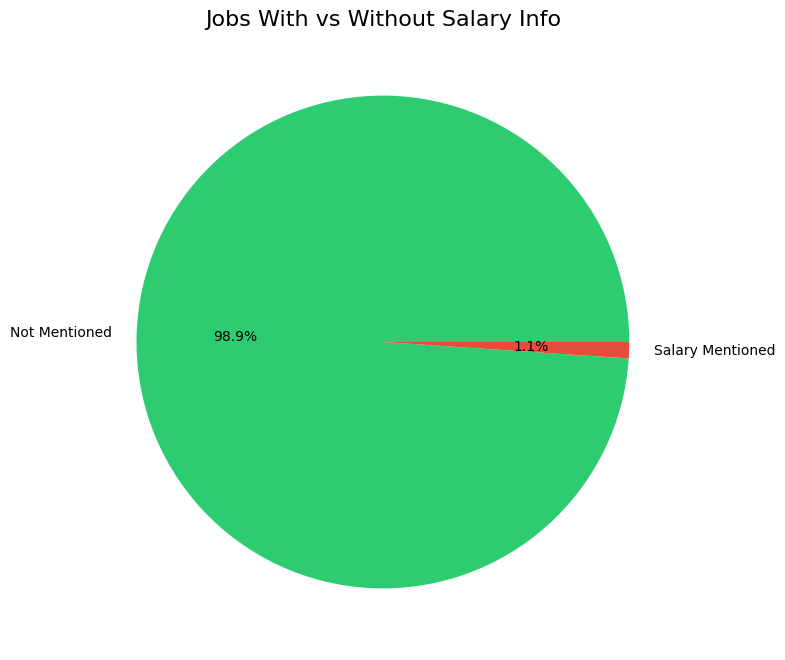

✅ Chart 3 Done!


In [17]:
# Chart 3: Salary Mentioned vs Not Mentioned
plt.figure(figsize=(8, 8))
salary_counts = df["Salary Range"].apply(
    lambda x: "Salary Mentioned" if x != "Not Mentioned" else "Not Mentioned"
).value_counts()
plt.pie(salary_counts.values, 
        labels=salary_counts.index, 
        autopct='%1.1f%%',
        colors=["#2ecc71", "#e74c3c"])
plt.title("Jobs With vs Without Salary Info", fontsize=16)
plt.savefig("salary_info.png")
plt.show()
print("✅ Chart 3 Done!")

In [18]:
# Step 10: Data CSV mein save karo
df.to_csv("remote_jobs.csv", index=False)
print("✅ Data CSV mein save ho gaya!")
print(f"✅ File: remote_jobs.csv")
print(f"✅ Total Jobs: {len(df)}")

✅ Data CSV mein save ho gaya!
✅ File: remote_jobs.csv
✅ Total Jobs: 94


In [19]:
# Final Summary
print("=" * 50)
print("   PROJECT SUMMARY - RemoteOK Job Analysis")
print("=" * 50)
print(f" Total Jobs Scraped: {len(df)}")
print(f" Unique Companies: {df['Company'].nunique()}")
print(f" Unique Countries: {df['Country'].nunique()}")
print(f" Jobs With Salary: {len(df[df['Salary Range'] != 'Not Mentioned'])}")
print(f" Date Range: {df['Date Posted'].min()} to {df['Date Posted'].max()}")
print("=" * 50)
print(" Project Complete!")

   PROJECT SUMMARY - RemoteOK Job Analysis
 Total Jobs Scraped: 94
 Unique Companies: 86
 Unique Countries: 24
 Jobs With Salary: 1
 Date Range: 2026-06-12 to 2026-06-18
 Project Complete!


In [20]:
# Excel file banao
df.to_excel("remote_jobs.xlsx", index=False, sheet_name="Remote Jobs")
print("✅ Excel file ban gayi!")
print("📁 File name: remote_jobs.xlsx")

✅ Excel file ban gayi!
📁 File name: remote_jobs.xlsx
